# 🚢 End-to-End Exploratory Data Analysis: Titanic Survival

> **Project Objective:** Perform a comprehensive, step-by-step EDA to uncover the key factors that influenced survival on the Titanic — covering data loading, cleaning, univariate/bivariate/multivariate analysis, feature engineering, correlation analysis, and automated profiling.

---

**Pipeline Overview:**

```
1. Setup              → Import libraries & configure aesthetics
2. Data Loading       → Load CSV, inspect shape, dtypes, missing values
3. Data Cleaning      → Impute Age/Embarked, engineer Has_Cabin flag
4. Univariate EDA     → Distribution of individual features
5. Bivariate EDA      → Feature vs. Survival relationships
6. Feature Engineering→ FamilySize, IsAlone, Title extraction
7. Multivariate EDA   → Cross-feature interactions
8. Correlation        → Heatmap of numerical features
9. Auto Profiling     → ydata-profiling report
10. Conclusion        → Key findings summary
```

---

## Step 1: Setup — Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## Step 2: Data Loading & Initial Inspection

We load the dataset and perform a first-pass inspection: shape, column types, and a quick statistical summary.

In [2]:
# Load the dataset
# Uncomment the line below to pull from the GeeksforGeeks repo if needed:
# !git clone 'https://github.com/GeeksforgeeksDS/21-Days-21-Projects-Dataset'

df = pd.read_csv('Titanic-Dataset.csv')

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset shape: 891 rows × 12 columns

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Last 5 rows — useful to spot data entry anomalies at the tail
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
# Concise structural summary: dtypes, non-null counts
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Interpretation of `.info()`:**
- The dataset has **891 entries** and **12 columns**.
- **Missing values identified:** `Age` (~177), `Cabin` (~687, ~77%), `Embarked` (2).
- `Cabin` is missing so heavily that direct imputation would be misleading.

In [5]:
# Descriptive statistics for numerical columns
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Interpretation of `.describe()`:**
- **Survived:** ~38.4% of passengers survived.
- **Age:** Ranges from ~5 months to 80 years; average ~30.
- **Fare:** Heavily right-skewed — mean ≈ $32, median ≈ $14.45, max > $512. Extreme outliers exist.

In [6]:
# Preview Cabin values — note the sparse, deck-coded nature
print("Cabin value counts (top 10):")
df['Cabin'].value_counts().head(10)

Cabin value counts (top 10):


Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
F2             3
D              3
C22 C26        3
C123           2
D33            2
Name: count, dtype: int64

---
## Step 3: Data Cleaning

We address the three columns with missing values using appropriate strategies:

| Column | Strategy | Rationale |
|---|---|---|
| `Age` | Fill with **median** | Skewed distribution; median is robust to outliers |
| `Embarked` | Fill with **mode** | Categorical field; 2 missing values → most frequent class |
| `Cabin` | **Binary flag** `Has_Cabin` | 77% missing — imputing would introduce too much noise |

In [7]:
print("Missing values BEFORE cleaning:")
print(df.isna().sum())

Missing values BEFORE cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
# --- 1. Age: fill with median ---
median_age = df['Age'].median()
print(f"Median Age: {median_age}")
df['Age'] = df['Age'].fillna(median_age)

print("Missing values after Age fix:")
print(df[['Age', 'Embarked', 'Cabin']].isna().sum())

Median Age: 28.0
Missing values after Age fix:
Age           0
Embarked      2
Cabin       687
dtype: int64


In [9]:
# --- 2. Embarked: fill with mode ---
mode_embarked = df['Embarked'].mode()[0]
print(f"Mode Embarked: {mode_embarked}")
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

print("Missing values after Embarked fix:")
print(df[['Age', 'Embarked', 'Cabin']].isna().sum())

Mode Embarked: S
Missing values after Embarked fix:
Age           0
Embarked      0
Cabin       687
dtype: int64


In [10]:
# --- 3. Cabin: create binary indicator, then drop original ---
# df['Cabin'].notna() → True if passenger has a cabin record
# .astype(int)        → converts True/False to 1/0
df['Has_Cabin'] = df['Cabin'].notna().astype(int)
df.drop('Cabin', axis=1, inplace=True)

print("Has_Cabin distribution:")
print(df['Has_Cabin'].value_counts())

Has_Cabin distribution:
Has_Cabin
0    687
1    204
Name: count, dtype: int64


In [11]:
# Final verification — no remaining missing values in treated columns
print("Missing values AFTER cleaning:")
print(df.isna().sum())
print("\nCleaned dataset preview:")
df.head(5)

Missing values AFTER cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64

Cleaned dataset preview:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


---
## Step 4: Univariate Analysis

We analyze each variable **individually** to understand its distribution before looking at relationships.

### 4.1 Categorical Features

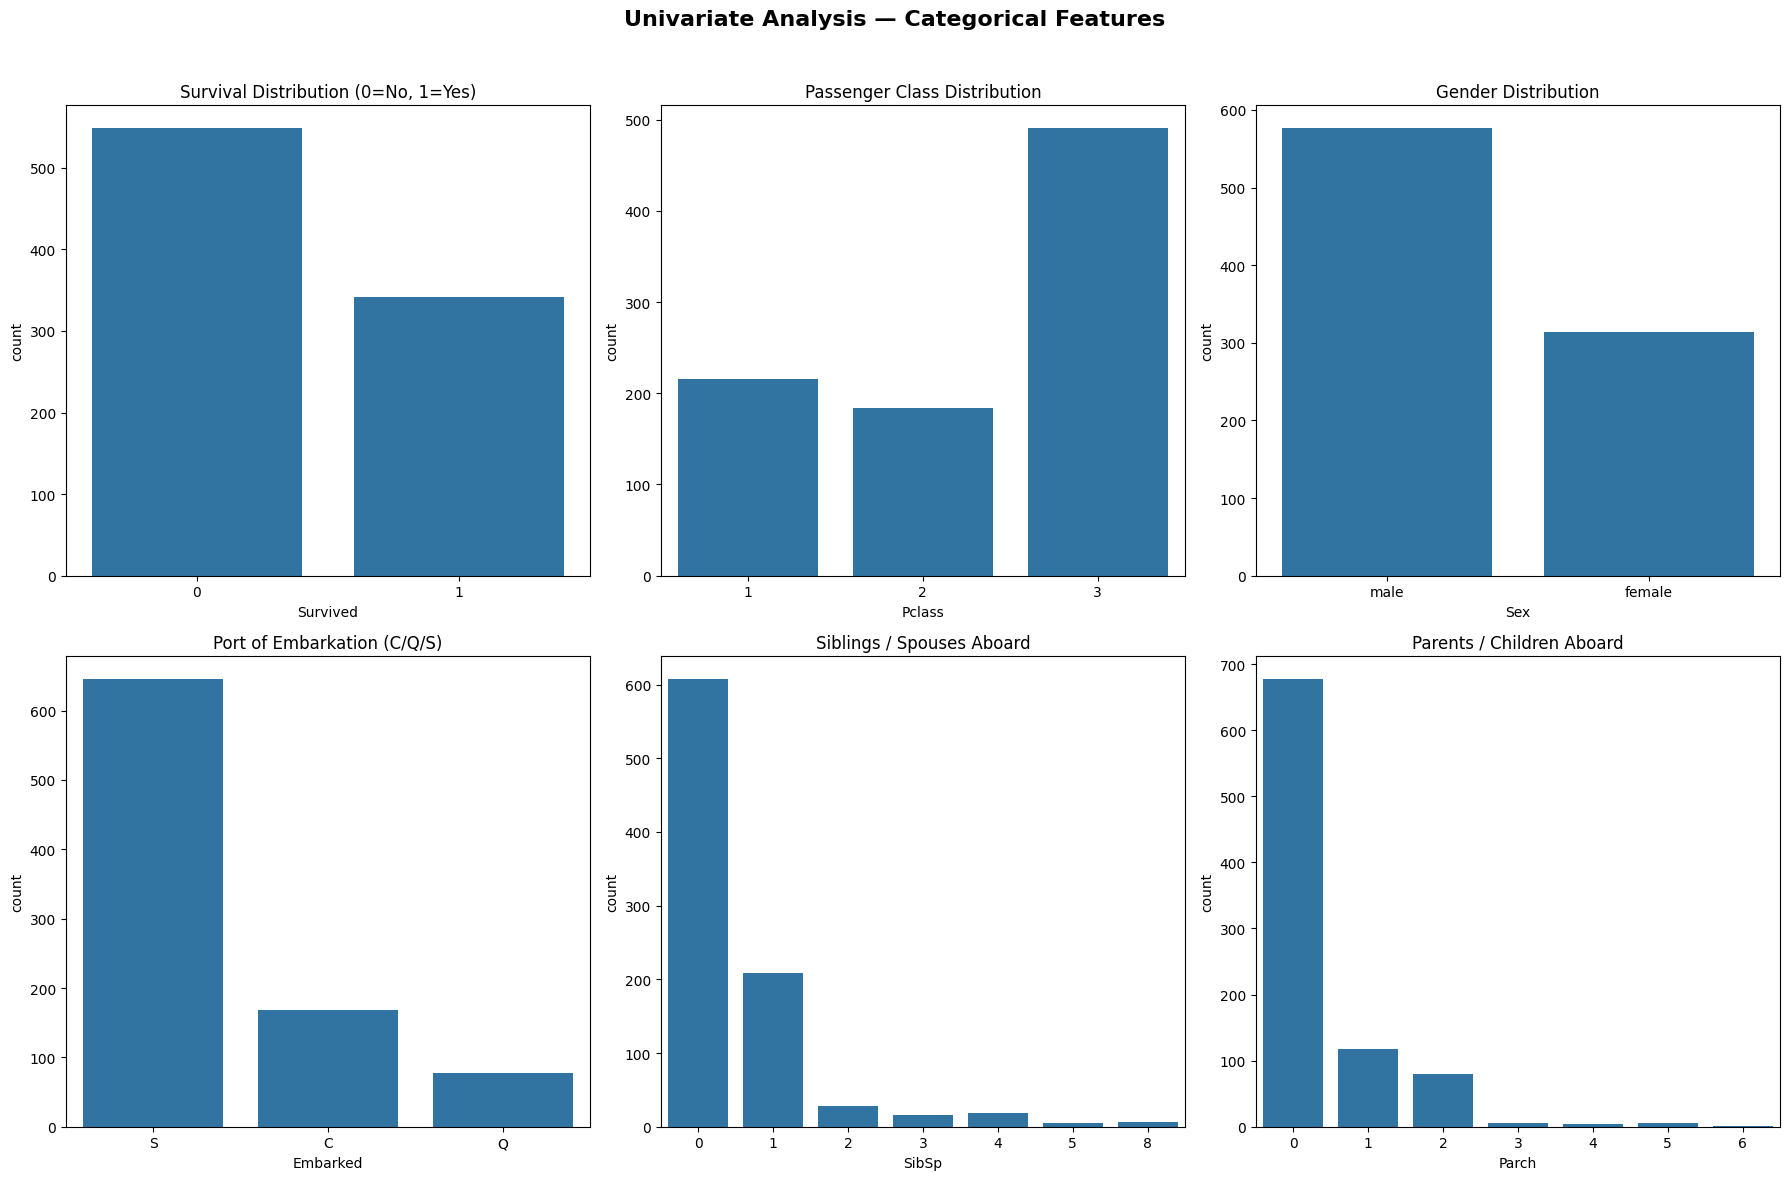

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Univariate Analysis — Categorical Features', fontsize=16, fontweight='bold')

sns.countplot(ax=axes[0, 0], x='Survived',  data=df).set_title('Survival Distribution (0=No, 1=Yes)')
sns.countplot(ax=axes[0, 1], x='Pclass',    data=df).set_title('Passenger Class Distribution')
sns.countplot(ax=axes[0, 2], x='Sex',       data=df).set_title('Gender Distribution')
sns.countplot(ax=axes[1, 0], x='Embarked',  data=df).set_title('Port of Embarkation (C/Q/S)')
sns.countplot(ax=axes[1, 1], x='SibSp',     data=df).set_title('Siblings / Spouses Aboard')
sns.countplot(ax=axes[1, 2], x='Parch',     data=df).set_title('Parents / Children Aboard')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Observations (Categorical):**
- **Survival:** Over 500 passengers (~61.6%) did not survive — class imbalance to be aware of for modelling.
- **Pclass:** 3rd class was most populated, followed by 1st, then 2nd.
- **Sex:** Significantly more males than females aboard.
- **Embarked:** Vast majority boarded at Southampton ('S').
- **SibSp / Parch:** Most passengers travelled alone or with at most 1 companion.

### 4.2 Numerical Features

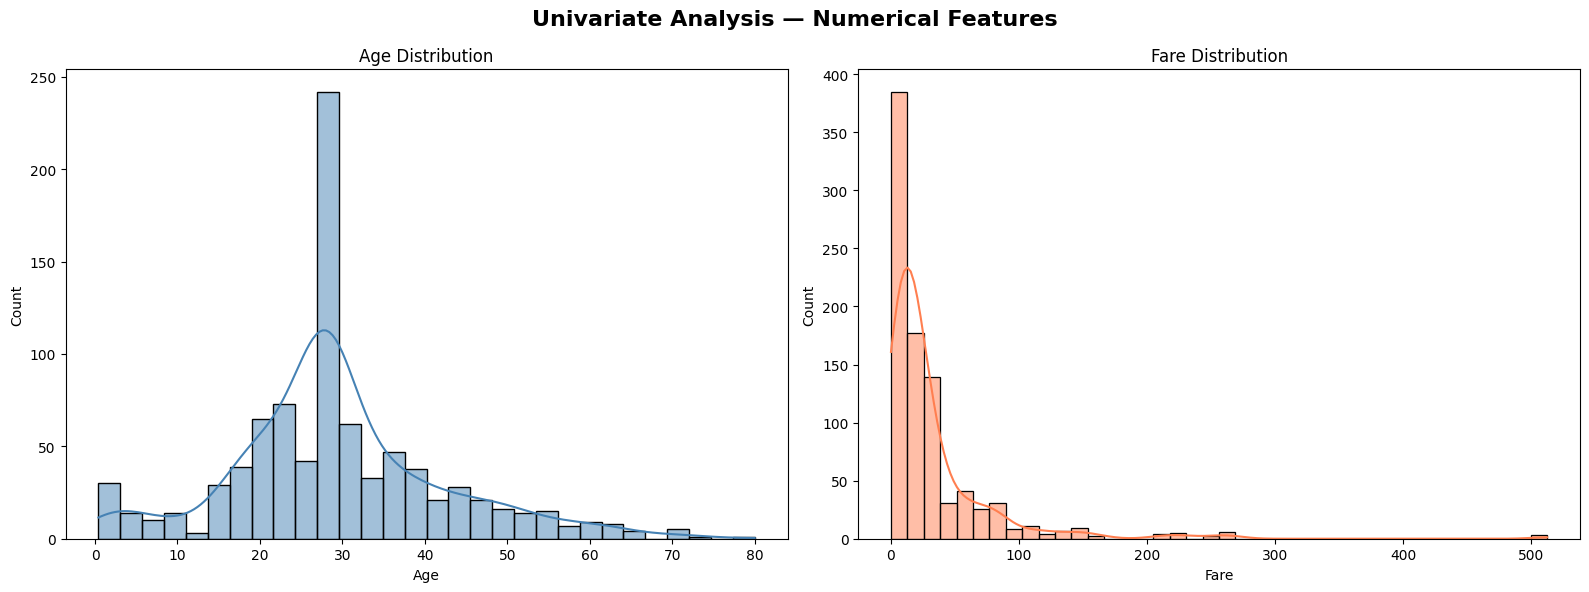

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Univariate Analysis — Numerical Features', fontsize=16, fontweight='bold')

sns.histplot(ax=axes[0], data=df, x='Age',  kde=True, bins=30, color='steelblue').set_title('Age Distribution')
sns.histplot(ax=axes[1], data=df, x='Fare', kde=True, bins=40, color='coral').set_title('Fare Distribution')

plt.tight_layout()
plt.show()

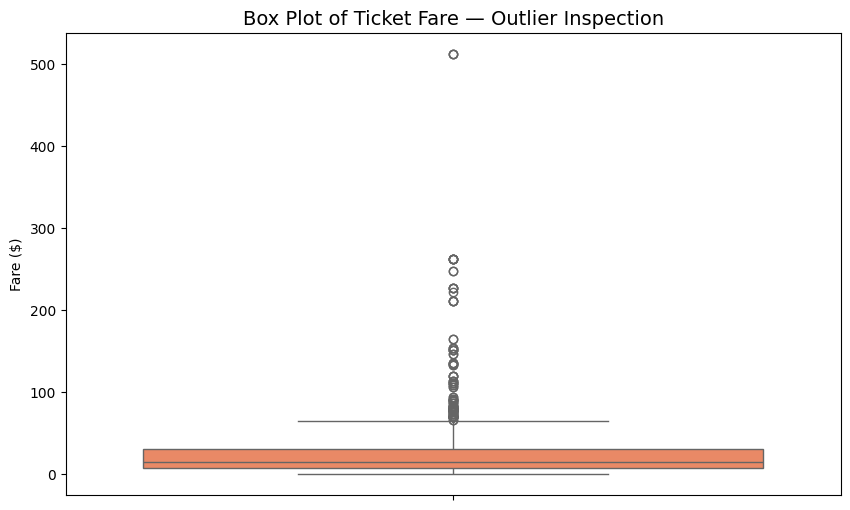

In [14]:
# Fare boxplot to highlight outliers clearly
plt.figure(figsize=(10, 6))
sns.boxplot(y='Fare', data=df, color='coral')
plt.title('Box Plot of Ticket Fare — Outlier Inspection', fontsize=14)
plt.ylabel('Fare ($)')
plt.show()

**Observations (Numerical):**
- **Age:** Peaks in the 20–30 range. The median imputation we applied contributes a slight artificial spike at ~28.
- **Fare:** Heavily right-skewed. Most tickets were below `$50`, but a few very expensive exceptions. These outliers suggest a **log transformation** would benefit ML models.

---
## Step 5: Bivariate Analysis

We examine how each feature **relates to the target variable `Survived`**.

### 5.1 Categorical Features vs. Survival

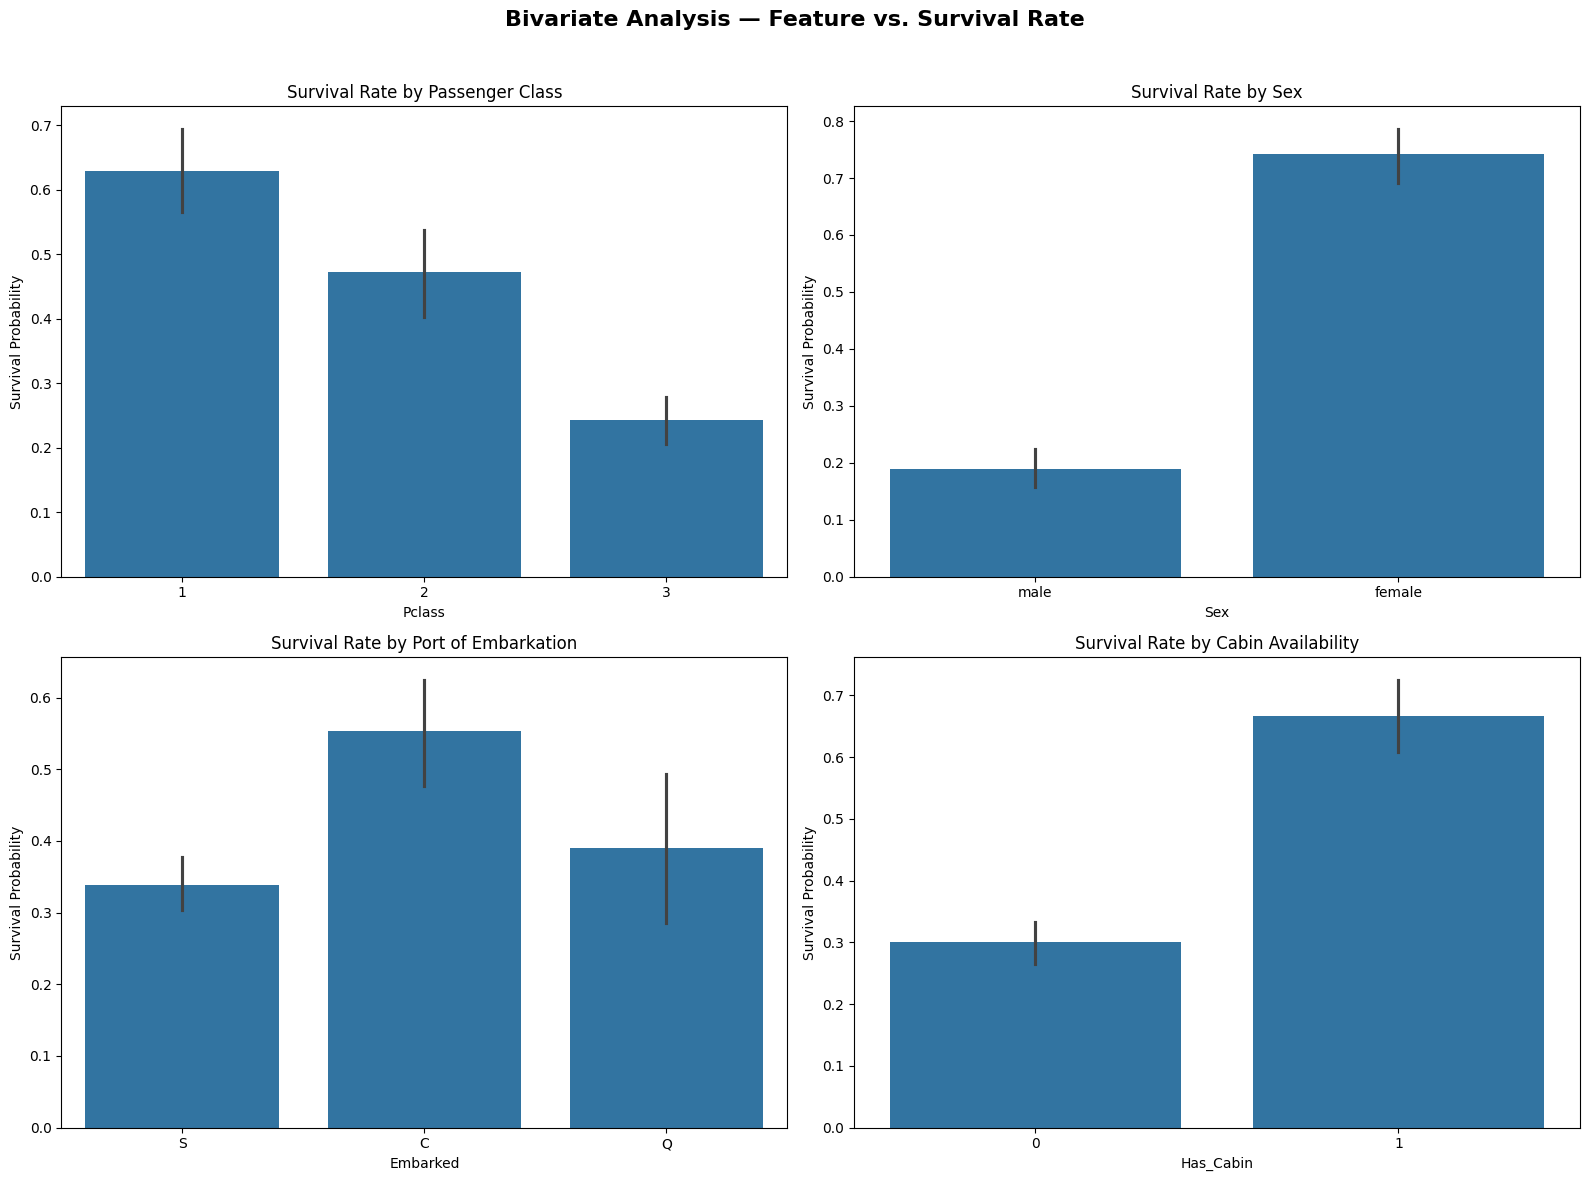

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bivariate Analysis — Feature vs. Survival Rate', fontsize=16, fontweight='bold')

sns.barplot(ax=axes[0, 0], x='Pclass',    y='Survived', data=df).set_title('Survival Rate by Passenger Class')
sns.barplot(ax=axes[0, 1], x='Sex',       y='Survived', data=df).set_title('Survival Rate by Sex')
sns.barplot(ax=axes[1, 0], x='Embarked',  y='Survived', data=df).set_title('Survival Rate by Port of Embarkation')
sns.barplot(ax=axes[1, 1], x='Has_Cabin', y='Survived', data=df).set_title('Survival Rate by Cabin Availability')

for ax in axes.flat:
    ax.set_ylabel('Survival Probability')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Observations:**
- **Pclass:** Clear survival hierarchy — 1st class >60%, 3rd class <25%.
- **Sex:** Strongest single predictor. Females ~75% survival rate vs. males <20%.
- **Embarked:** Cherbourg ('C') passengers had the highest survival rate, likely due to a higher concentration of 1st class travellers.
- **Has_Cabin:** Passengers with a registered cabin survived at nearly double the rate — a proxy for wealth and class.

### 5.2 Age vs. Survival

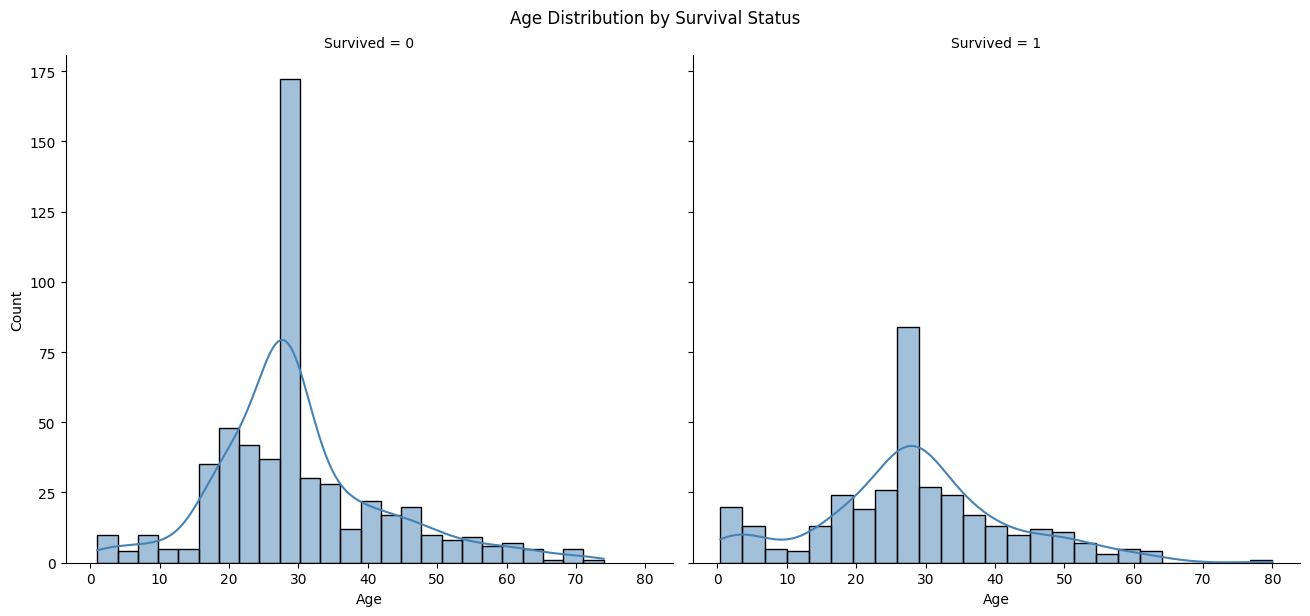

In [16]:
g = sns.FacetGrid(df, col='Survived', height=6, aspect=1.1)
g.map(sns.histplot, 'Age', bins=25, kde=True, color='steelblue')
g.set_axis_labels('Age', 'Count')
plt.suptitle('Age Distribution by Survival Status', y=1.02)
plt.show()

**Observations:**
- Infants and young children had a notably higher survival probability.
- The bulk of non-survivors were young adults (20–40).
- The oldest passengers (near 80) did not survive.

---
## Step 6: Feature Engineering

We create **new, more informative features** from existing raw columns using domain knowledge.

> *Good features should be relevant to the problem and easy for a model to interpret.*

**Techniques used:**
1. **Combining** — `FamilySize` from `SibSp + Parch`
2. **Binarizing** — `IsAlone` from `FamilySize`
3. **Extracting from text** — `Title` from `Name` via regex

### 6.1 FamilySize & IsAlone

In [17]:
# FamilySize: total people travelling with the passenger (+1 for themselves)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone: binary flag — 1 if travelling solo
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("Family size distribution:")
print(df[['FamilySize', 'IsAlone']].head())
print(df['FamilySize'].value_counts().sort_index())
print(f"\nTravelling alone: {df['IsAlone'].sum()} passengers ({df['IsAlone'].mean()*100:.1f}%)")

Family size distribution:
   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Travelling alone: 537 passengers (60.3%)


C:\Users\sudwa\AppData\Local\Temp\ipykernel_15864\165233467.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['With Family (0)', 'Alone (1)'])


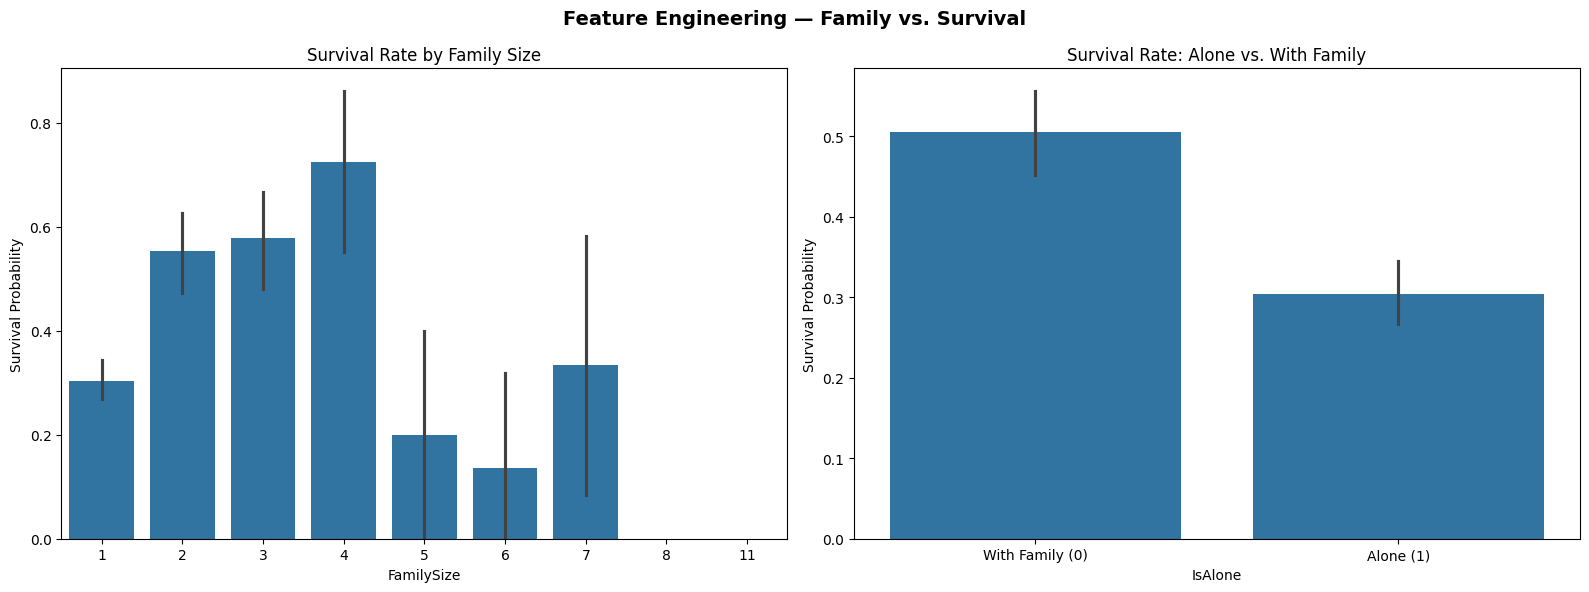

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Engineering — Family vs. Survival', fontsize=14, fontweight='bold')

sns.barplot(ax=axes[0], x='FamilySize', y='Survived', data=df)
axes[0].set_title('Survival Rate by Family Size')
axes[0].set_ylabel('Survival Probability')

sns.barplot(ax=axes[1], x='IsAlone', y='Survived', data=df)
axes[1].set_title('Survival Rate: Alone vs. With Family')
axes[1].set_xticklabels(['With Family (0)', 'Alone (1)'])
axes[1].set_ylabel('Survival Probability')

plt.tight_layout()
plt.show()

**Observations:**
- Passengers travelling **alone** had a ~30% survival rate — lower than those with small families.
- **Small families (2–4)** had the highest survival rates — perhaps easier to stay coordinated during evacuation.
- **Very large families (5+)** had poor survival — harder to coordinate evacuations together.

### 6.2 Title Extraction from Name

The `Name` column encodes social title information (Mr, Mrs, Miss, Master, etc.) that is a strong proxy for **age, sex, and social status**.

**Regex pattern:** `r' ([A-Za-z]+)\.'`
- ` ` → matches the space preceding the title
- `([A-Za-z]+)` → capturing group for one or more letters (the title)
- `\.` → matches the literal `.` that follows the title

In [19]:
# Extract title from Name using regex
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print("Extracted Titles:")
print(df['Title'].value_counts())

Extracted Titles:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [20]:
# Consolidate rare titles → 'Rare' and normalise French variants
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print("Simplified Titles:")
print(df['Title'].value_counts())

Simplified Titles:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


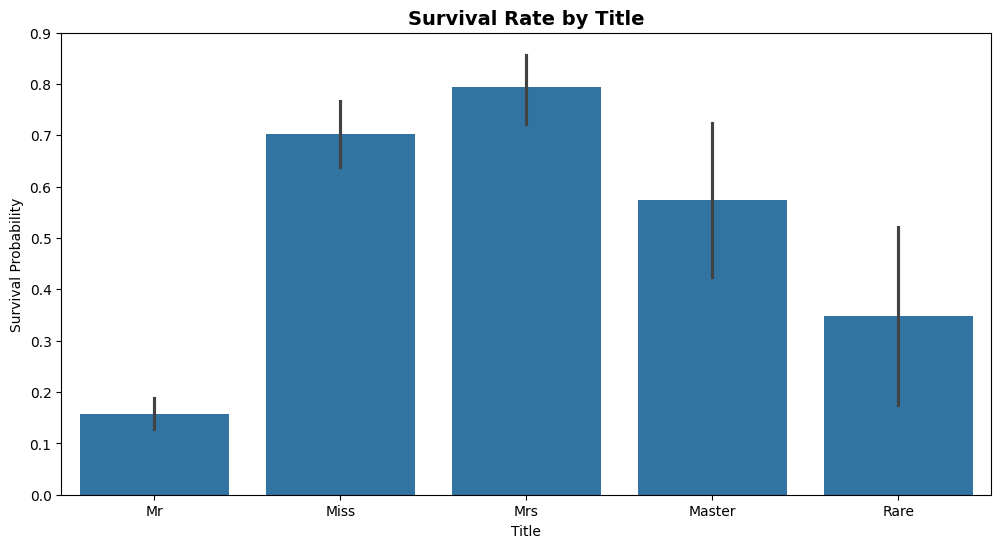

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Title', y='Survived', data=df, order=['Mr', 'Miss', 'Mrs', 'Master', 'Rare'])
plt.title('Survival Rate by Title', fontsize=14, fontweight='bold')
plt.ylabel('Survival Probability')
plt.xlabel('Title')
plt.show()

**Observations:**
- **Mrs / Miss** (females) had high survival rates, reinforcing the 'women first' policy.
- **Mr** (adult males) had a very low survival rate (<20%).
- **Master** (young boys) survived significantly more than adult men — the 'children first' effect.
- **Rare** titles (nobility/officials) had moderate-to-high survival — likely linked to 1st class access.

---
## Step 7: Multivariate Analysis

We now explore **interactions between multiple variables simultaneously** — revealing patterns that univariate and bivariate analyses miss.

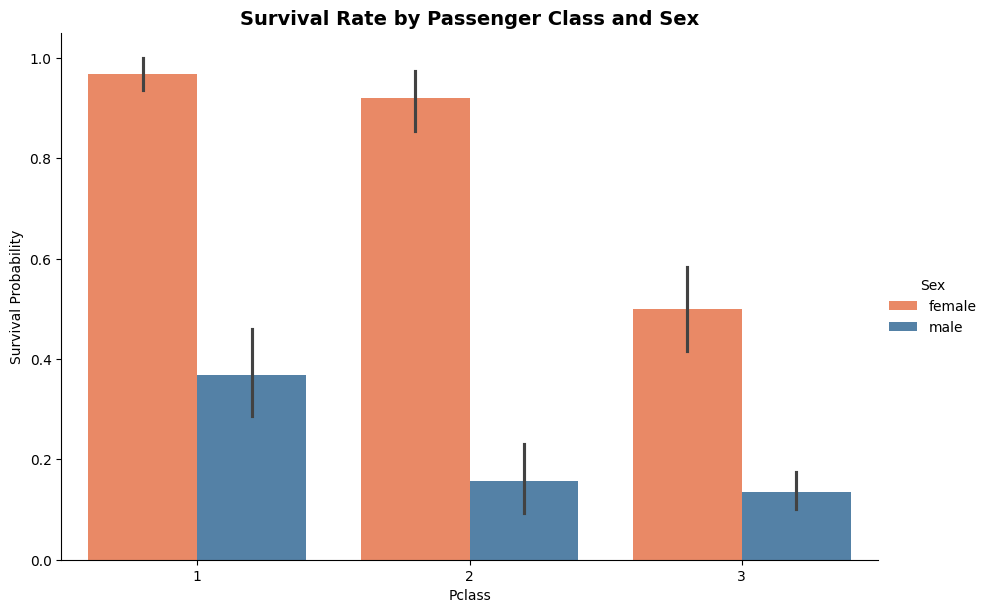

In [22]:
# Survival Rate broken down by both Pclass AND Sex
sns.catplot(
    x='Pclass', y='Survived', hue='Sex',
    data=df, kind='bar',
    height=6, aspect=1.5,
    palette={'male': 'steelblue', 'female': 'coral'}
)
plt.title('Survival Rate by Passenger Class and Sex', fontsize=14, fontweight='bold')
plt.ylabel('Survival Probability')
plt.show()

**Observation:** Females in **all three classes** had a much higher survival rate than males in the same class. Even 3rd-class females (~50%) outperformed 1st-class males (~37%). The sex effect dominates across all classes.

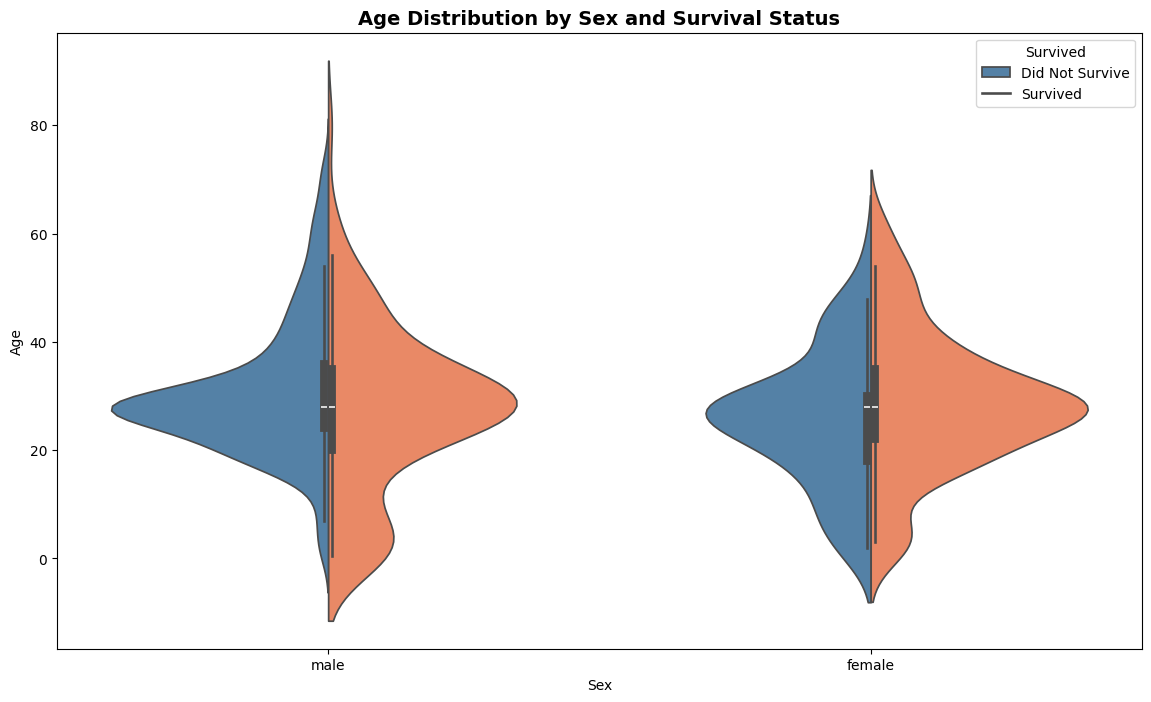

In [23]:
# Violin plot: age distribution by sex AND survival
plt.figure(figsize=(14, 8))
sns.violinplot(
    x='Sex', y='Age', hue='Survived',
    data=df, split=True,
    palette={0: 'steelblue', 1: 'coral'}
)
plt.title('Age Distribution by Sex and Survival Status', fontsize=14, fontweight='bold')
plt.legend(title='Survived', labels=['Did Not Survive', 'Survived'])
plt.show()

**Observations (Violin Plot):**
- **Males:** Survivors are concentrated at very young ages (children). Non-survivors peak at 20–30.
- **Females:** Survivors spread across almost all ages — women of any age had a good chance of survival.

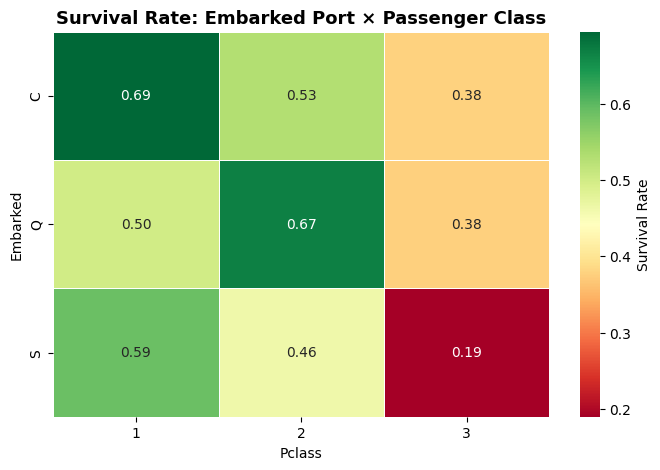

In [24]:
# Heatmap: survival rate by Pclass × Embarked
pivot = df.pivot_table(values='Survived', index='Embarked', columns='Pclass', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5,
            cbar_kws={'label': 'Survival Rate'})
plt.title('Survival Rate: Embarked Port × Passenger Class', fontsize=13, fontweight='bold')
plt.show()

**Observation:** Cherbourg ('C') 1st-class passengers had the highest survival rate. Southampton ('S') 3rd-class passengers had the lowest. The pattern reinforces that class and embarkation port are correlated.

---
## Step 8: Correlation Analysis

A correlation heatmap shows how **numerical features relate to each other** and to the target variable `Survived`.

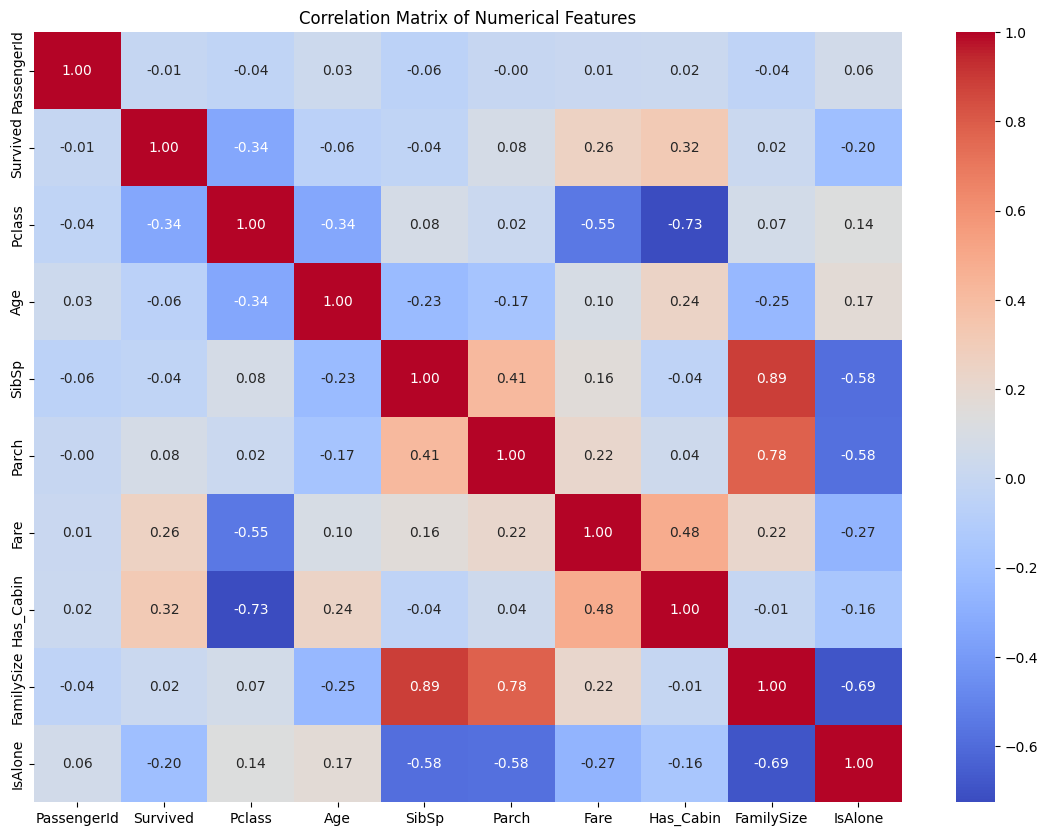

In [25]:
# Correlation Heatmap for numerical features
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=np.number)
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Interpretation:**
- **`Survived`** correlates positively with `Fare` (+) and `Has_Cabin` (+), and negatively with `Pclass` (−) and `IsAlone` (−).
- **`Pclass` ↔ `Fare`**: Strong negative correlation (−0.55) — higher class = higher fare.
- **`FamilySize`** is naturally correlated with `SibSp` and `Parch` (it's derived from them).
- **`Has_Cabin` ↔ `Pclass`**: Moderate negative correlation — cabin records are mostly 1st class.

---
## Step 9: Automated Profiling with ydata-profiling

`ydata-profiling` automatically generates a comprehensive, interactive data analysis report that summarises:
- Data types, missing values, and distributions
- Correlations and potential data quality issues
- Alerts for duplicates, high cardinality, etc.

In [27]:
# Install if not already available
!pip install ydata-profiling -q

In [28]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Titanic Dataset — EDA Profiling Report",
    explorative=True
)

# Display interactively inside the notebook
profile.to_notebook_iframe()

ModuleNotFoundError: No module named 'ydata_profiling'

In [ ]:
# Save the full report as a standalone HTML file
profile.to_file("Titanic_Profiling_Report.html")
print("✅ Report saved to Titanic_Profiling_Report.html")

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

class EDAAgent:
    def __init__(self, df: pd.DataFrame, target: str = None):
        self.df = df
        self.target = target
        self.report = {}

    def run(self):
        display(Markdown("# 📊 EDA Report"))

        self.show_basic_info()
        self.show_missing()
        self.show_distributions()
        self.show_correlation()
        self.detect_outliers()
        self.generate_insights()

    def show_basic_info(self):
        display(Markdown("## 🧾 Dataset Overview"))
        display(self.df.head())

        display(Markdown("### Shape"))
        print(self.df.shape)

        display(Markdown("### Data Types"))
        display(self.df.dtypes)

    def show_missing(self):
        display(Markdown("## ⚠️ Missing Values"))
        missing = self.df.isnull().sum()
        missing_pct = (self.df.isnull().mean() * 100)

        missing_df = pd.DataFrame({
            "Missing Count": missing,
            "Missing %": missing_pct
        }).sort_values("Missing %", ascending=False)

        display(missing_df)

        # Plot
        missing_pct.plot(kind="bar", title="Missing Values (%)")
        plt.show()

        self.report["missing"] = missing_df.to_dict()

    def show_distributions(self):
        display(Markdown("## 📈 Distributions"))

        num_cols = self.df.select_dtypes(include=np.number).columns

        for col in num_cols:
            plt.figure()
            sns.histplot(self.df[col], kde=True)
            plt.title(f"{col}")
            plt.show()

    def show_correlation(self):
        display(Markdown("## 🔗 Correlation"))

        corr = self.df.corr(numeric_only=True)

        plt.figure(figsize=(10, 6))
        sns.heatmap(corr, annot=False)
        plt.title("Correlation Heatmap")
        plt.show()

        self.report["correlation"] = corr

    def detect_outliers(self):
        display(Markdown("## 🚨 Outliers"))

        outliers = {}

        for col in self.df.select_dtypes(include=np.number).columns:
            q1 = self.df[col].quantile(0.25)
            q3 = self.df[col].quantile(0.75)
            iqr = q3 - q1

            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            count = ((self.df[col] < lower) | (self.df[col] > upper)).sum()
            outliers[col] = count

        display(pd.Series(outliers, name="Outlier Count"))
        self.report["outliers"] = outliers

    def generate_insights(self):
        display(Markdown("## 🧠 Insights"))

        insights = []

        # Missing
        for col, pct in self.df.isnull().mean().items():
            if pct > 0.3:
                insights.append(f"⚠️ {col} has high missing values ({pct:.2%})")

        # Outliers
        for col, count in self.report["outliers"].items():
            if count > 0:
                insights.append(f"🚨 {col} has {count} outliers")

        # Correlation
        corr = self.df.corr(numeric_only=True)
        for col in corr.columns:
            for idx in corr.index:
                if col != idx and abs(corr.loc[idx, col]) > 0.8:
                    insights.append(f"🔗 Strong correlation: {idx} vs {col}")

        if insights:
            for i in insights:
                display(Markdown(f"- {i}"))
        else:
            display(Markdown("No major issues detected ✅"))

# 📊 EDA Report

## 🧾 Dataset Overview

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Shape

(891, 12)


### Data Types

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

## ⚠️ Missing Values

,Missing Count,Missing %
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


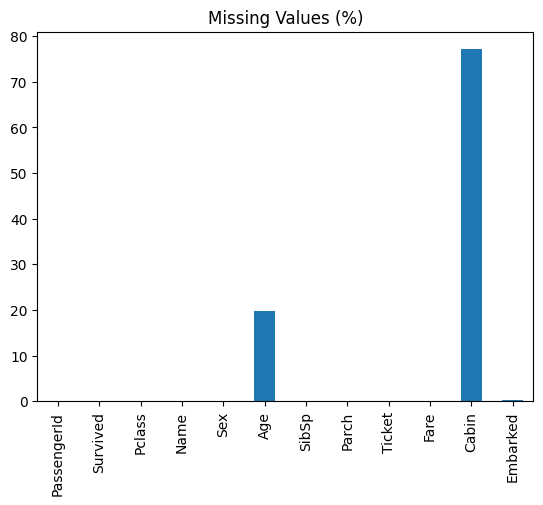

## 📈 Distributions

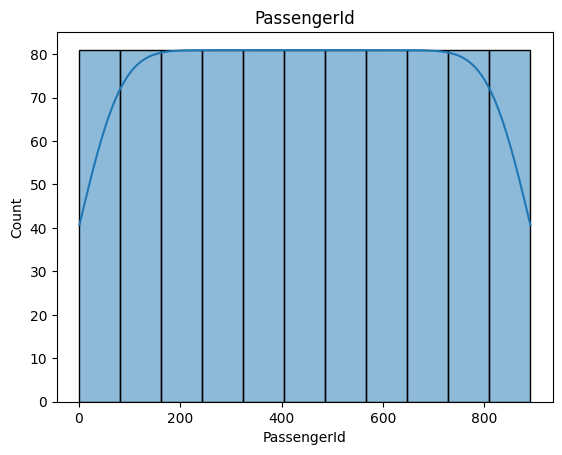

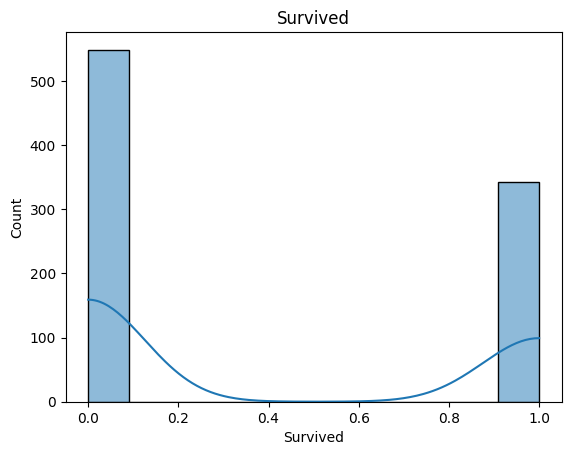

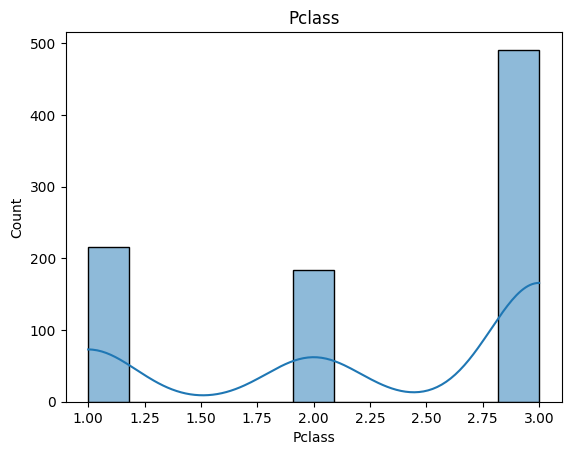

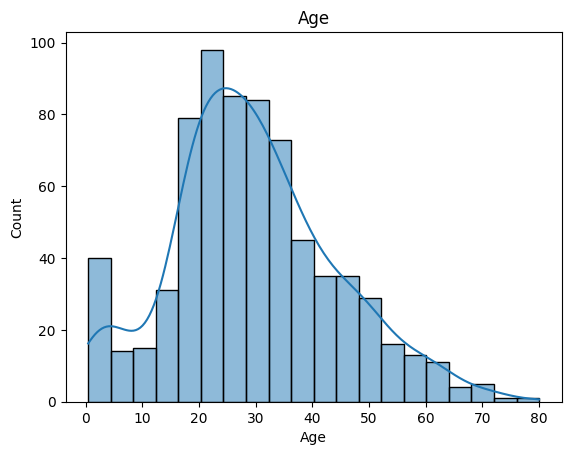

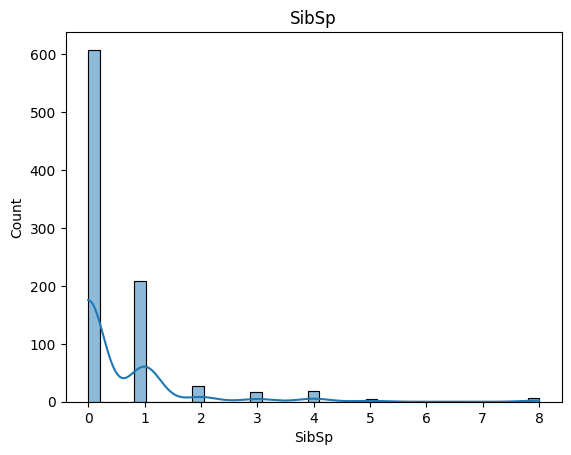

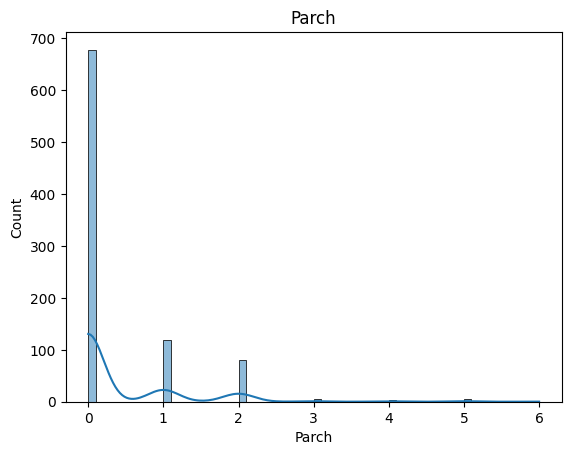

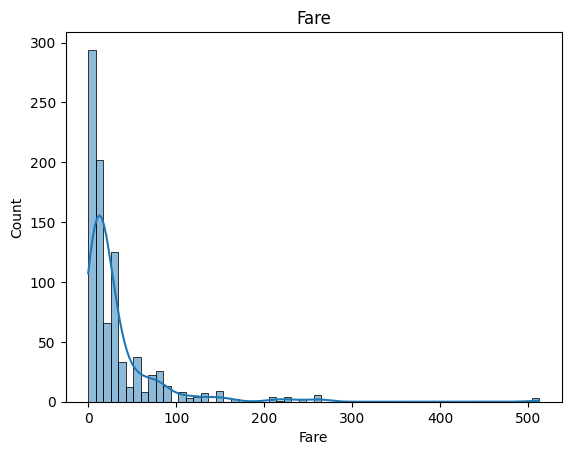

## 🔗 Correlation

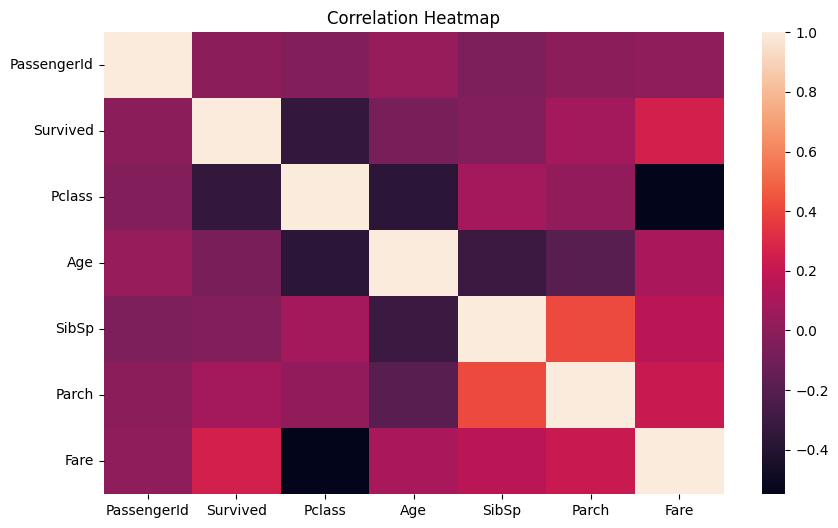

## 🚨 Outliers

PassengerId      0
Survived         0
Pclass           0
Age             11
SibSp           46
Parch          213
Fare           116
Name: Outlier Count, dtype: int64

## 🧠 Insights

- ⚠️ Cabin has high missing values (77.10%)

- 🚨 Age has 11 outliers

- 🚨 SibSp has 46 outliers

- 🚨 Parch has 213 outliers

- 🚨 Fare has 116 outliers

In [31]:
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')

eda = EDAAgent(df, target="Survived")
eda.run()

---
## Step 10: Final Conclusions & Summary of Insights

This end-to-end EDA confirms the *"women and children first"* narrative and reveals stark socioeconomic inequalities.

---

### 🔑 Key Findings

#### Primary Survival Predictors

| Feature | Finding |
|---|---|
| **Sex / Title** | Females (~75% survival) vastly outpaced males (<20%). `Title` captures nuance: 'Master' (boys) survived far more than 'Mr' (men). |
| **Passenger Class** | Clear survival hierarchy: 1st (>60%) > 2nd (~47%) > 3rd (<25%). |
| **Age** | Children/infants had elevated survival. Young adult males (20–40) were most at risk. |

#### Secondary Influences

| Feature | Finding |
|---|---|
| **FamilySize / IsAlone** | Small families (2–4) had the best odds. Solo travellers and large families (5+) fared worse. |
| **Fare / Has_Cabin** | Higher fare and cabin possession strongly correlate with survival — proxies for wealth and class. |
| **Embarkation Port** | Cherbourg ('C') passengers had higher survival rates, linked to their higher proportion of 1st-class travellers. |

---

### 🔧 Engineered Features Created

| Feature | Type | Source |
|---|---|---|
| `Has_Cabin` | Binary flag | `Cabin` |
| `FamilySize` | Integer | `SibSp + Parch + 1` |
| `IsAlone` | Binary flag | `FamilySize == 1` |
| `Title` | Categorical | Regex extraction from `Name` |

---

### ➡️ Next Steps (ML Pipeline)

1. **Encode** categorical variables (`Sex`, `Embarked`, `Title`) via one-hot or label encoding
2. **Scale** numerical features (`Age`, `Fare`) — consider log-transform for `Fare`
3. **Model** with a baseline (Logistic Regression), then tree-based models (Random Forest, XGBoost)
4. **Evaluate** with cross-validation (AUC-ROC, precision-recall) given class imbalance
5. **Interpret** with SHAP values to quantify feature importance